<a href="https://colab.research.google.com/github/Praneethgajula01/aml-0026/blob/main/AML_Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#------------------------------------------------DECISION TREE CLASSIFIER-----------------------------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'FLUENT_PYTHON.pdf',
 '1st edition fluent python .pdf',
 'cheat sheet for conda commands ',
 'APAAR ID ',
 'MINI PROJECT .pdf',
 'AML DATASET',
 'AIML_ResourceList']

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Social_Network_Ads.csv')
display(dataset.head())

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
dataset.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

In [ ]:
X

array([[    19,  19000],
       [    35,  20000],
       [    26,  43000],
       [    27,  57000],
       [    19,  76000],
       [    27,  58000],
       [    27,  84000],
       [    32, 150000],
       [    25,  33000],
       [    35,  65000],
       [    26,  80000],
       [    26,  52000],
       [    20,  86000],
       [    32,  18000],
       [    18,  82000],
       [    29,  80000],
       [    47,  25000],
       [    45,  26000],
       [    46,  28000],
       [    48,  29000],
       [    45,  22000],
       [    47,  49000],
       [    48,  41000],
       [    45,  22000],
       [    46,  23000],
       [    47,  20000],
       [    49,  28000],
       [    47,  30000],
       [    29,  43000],
       [    31,  18000],
       [    31,  74000],
       [    27, 137000],
       [    21,  16000],
       [    28,  44000],
       [    27,  90000],
       [    35,  27000],
       [    33,  28000],
       [    30,  49000],
       [    26,  72000],
       [    27,  31000],


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0
)

In [ ]:
print(X_test)

[[    30  87000]
 [    38  50000]
 [    35  75000]
 [    30  79000]
 [    35  50000]
 [    27  20000]
 [    31  15000]
 [    36 144000]
 [    18  68000]
 [    47  43000]
 [    30  49000]
 [    28  55000]
 [    37  55000]
 [    39  77000]
 [    20  86000]
 [    32 117000]
 [    37  77000]
 [    19  85000]
 [    55 130000]
 [    35  22000]
 [    35  47000]
 [    47 144000]
 [    41  51000]
 [    47 105000]
 [    23  28000]
 [    49 141000]
 [    28  87000]
 [    29  80000]
 [    37  62000]
 [    32  86000]
 [    21  88000]
 [    37  79000]
 [    57  60000]
 [    37  53000]
 [    24  58000]
 [    18  52000]
 [    22  81000]
 [    34  43000]
 [    31  34000]
 [    49  36000]
 [    27  88000]
 [    41  52000]
 [    27  84000]
 [    35  20000]
 [    43 112000]
 [    27  58000]
 [    37  80000]
 [    52  90000]
 [    26  30000]
 [    49  86000]
 [    57 122000]
 [    34  25000]
 [    35  57000]
 [    34 115000]
 [    59  88000]
 [    45  32000]
 [    29  83000]
 [    26  80000]
 [    49  2800

In [ ]:
#FITTING DESICION TREE CLASSIFICATION TO THE TRAINING SET

from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
y_pred=classifier.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1])

In [ ]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1])

In [ ]:
#making the confusion matrix

from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test, y_pred)
print("0,0: ",cm[0][0])
print("0,1: ",cm[0][1])
print("1,0: ",cm[1][0])
print("1,1: ",cm[1][1])

0,0:  62
0,1:  6
1,0:  3
1,1:  29


In [ ]:
import sklearn.metrics as metrics
prediction=metrics.accuracy_score(y_test, y_pred)
print("Accuracy: ",prediction*100,"%")

Accuracy:  91.0 %


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        68
           1       0.83      0.91      0.87        32

    accuracy                           0.91       100
   macro avg       0.89      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



In [ ]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
# It's important to transform new data with the *same* scaler fitted on the training data
new_individual=np.array([27, 89000])
new_individual_scaled=sc_X.transform(new_individual.reshape(1, -1))
new_individual_scaled

prediction=classifier.predict(new_individual_scaled)
if prediction[0]==0:
  print("person will not purchase")
else:
  print("person purchased")

person will not purchase


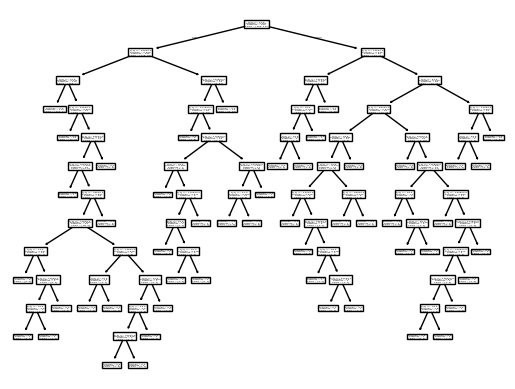

In [ ]:
from sklearn import tree

tree.plot_tree(classifier)
plt.show()

In [ ]:
dataset2=pd.read_csv('/content/drive/MyDrive/diabetes.csv')
display(dataset2.head())

In [ ]:
dataset2.isnull().sum()

In [ ]:
X=dataset2[["Glucose","BMI", "Age"]].values
X

In [ ]:
y=dataset2.iloc[:, -1].values
y

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0
)

In [ ]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

X_train=sc_X.fit_transform(X_train)
X_test=sc_X.transform(X_test)
print(X_train)
print(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)

classifier.fit(X_train, y_train)


In [ ]:
y_pred=classifier.predict(X_test)
y_pred

In [ ]:
y_test

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test, y_pred)
cm

In [ ]:
import sklearn.metrics as metrics
prediction=metrics.accuracy_score(y_test, y_pred)
print(prediction*100)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn import tree

tree.plot_tree(classifier)
plt.show()

In [ ]:
dataset3=pd.read_csv('/content/drive/MyDrive/Iris(1).csv')
display(dataset3.head())

In [ ]:
dataset3.isnull().sum()

In [ ]:
X=dataset3.iloc[:, 1:-1].values
X

In [ ]:
y=dataset3.iloc[:, -1].values
y

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0
)


In [ ]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

X_train=sc_X.fit_transform(X_train)
X_test=sc_X.transform(X_test)
print(X_train)
print(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

In [ ]:
y_pred=classifier.predict(X_test)
y_pred

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test, y_pred)
cm

In [ ]:
import sklearn.metrics as metrics
prediction=metrics.accuracy_score(y_test, y_pred)
print("Accuracy: ",prediction*100,"%")

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn import tree

tree.plot_tree(classifier)
plt.show()

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X=np.array([1,2,3,4,5]).reshape(-1, 1)
X

In [ ]:
y=np.array([40, 50, 50, 60, 70])
y

In [ ]:
model=LinearRegression()
reg=model.fit(X,y)
reg

In [ ]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

In [ ]:
new_data=np.array([[6]])
predicted_mark=model.predict(new_data)

predicted_mark[0]

In [ ]:
y_pred=model.predict(X)
y_pred

In [ ]:
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, y_pred, color="red", label="Pred data")

plt.xlabel("study hours")
plt.ylabel("Marks")
plt.title("Study hrs vs marks")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)


mae=mean_absolute_error(y, y_pred)
mse=mean_squared_error(y, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y, y_pred)

print("mae:", mae)

print("mse:", mse)

print("rmse:", rmse)

print("r2:", r2)

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
data={
    "Study_hours":[1,2,3,4,5,6,7,8,9,10],
    "Marks":[32, 38, 43, 50, 54, 61, 68, 73, 81, 80]
}

In [ ]:
df=pd.DataFrame(data)
df

In [ ]:
X=df[["Study_hours"]]
y=df["Marks"]
X
y

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

model=LinearRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("Actual Income:", y_test.values)
print("Pred values:", y_pred)

In [ ]:
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)

print("mae:", mae)

print("mse:", mse)

print("rmse:", rmse)

print("r2:", r2)

Multiple Linear Regression


In [ ]:
data={
    "Study_hours": [2,3,4,5,6,7,8,9],
    "Attendance": [60, 65, 70, 75, 79, 83, 91, 95],
    "Assignment_score": [50, 55, 58, 65, 70, 74, 80, 88],
    "Final_marks":[42, 48, 54, 61, 67, 79, 81, 89]
}



df=pd.DataFrame(data)
df

In [ ]:
X=df[["Study_hours", "Attendance", "Assignment_score"]]
y=df["Final_marks"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
model=LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
y_pred=model.predict(X_test)


In [ ]:
coefficient_table=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient": model.coef_
})

coefficient_table

In [ ]:
new_student=pd.DataFrame({
    "Study_hours":[6],
    "Attendance":[82],
    "Assignment_score":[72]
})

In [ ]:
prediction=model.predict(new_student)
print("pred for new student:", prediction[0])

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

minimum=min(y_test.min(), y_pred.min())
maximum=min(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--"

)

plt.xlabel("Actual")
plt.ylabel("Predictor")
plt.title("Actual vs pred")
plt.show()

residual plot


In [ ]:
residuals=y_test-y_pred

plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("pred values")
plt.ylabel("residuals")
plt.title("residual plot")
plt.grid()
plt.show()

In [ ]:
import pandas as pd

data={
    "Size":[800, 1000, 1200, 1500, 1800],
    "Location":["Rural", "Urban", "Rural", "Urban", "Urban"],
    "Price":[30, 50, 42, 72, 85]
}

df=pd.DataFrame(data)
df

In [ ]:
df_encoded=pd.get_dummies(
    df, columns=["Location"], drop_first=True, dtype=int
)

print(df_encoded)

In [ ]:
X=df_encoded[[ "Size","Location_Urban"]]
y=df_encoded["Price"]

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
model=LinearRegression()
model.fit(X_train, y_train)


In [ ]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
y_pred=model.predict(X_test)

In [ ]:
new_data=np.array([[6, 0]]) # Assuming Size=6 and Location_Urban=0 (Rural)
predicted_price=model.predict(new_data)

predicted_price[0]

In [ ]:
coefficient_table=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient": model.coef_
})

coefficient_table

In [ ]:
y_pred=model.predict(X)
y_pred

In [ ]:
plt.scatter(y, y_pred, color="blue", label="Actual vs Predicted")

# Add a diagonal line for perfect prediction
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Ideal Fit")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)


mae=mean_absolute_error(y, y_pred)
mse=mean_squared_error(y, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y, y_pred)

print("mae:", mae)

print("mse:", mse)

print("rmse:", rmse)

print("r2:", r2)

income data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

os.listdir('/content/drive/MyDrive')

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/income_data.csv')
display(dataset.head())